# MLB Pitcher Cy Young Predictor - Modeling

## Section 0: Setup & Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load master dataset
master = pd.read_csv('../Data/Processed/master_dataset.csv')
print('Master dataset shape:', master.shape)

# Define feature sets
linear_features = ['SIERA', 'WAR', 'LOB%', 'W', 'L']

tree_features = ['xERA', 'SIERA', 'WAR', 'K%', 'HR/9', 'BB%', 
                 'K-BB%', 'K/BB', 'WHIP', 'BABIP', 'LOB%',
                 'ERA-', 'FIP-', 'IP', 'W', 'L']

arsenal_features = [
    'FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%',
    'vFA', 'vSI', 'vFC', 'vSL', 'vCU', 'vCH', 'vFS', 'vKC',
    'FA-X', 'SI-X', 'FC-X', 'SL-X', 'CU-X', 'CH-X', 'FS-X', 'KC-X',
    'FA-Z', 'SI-Z', 'FC-Z', 'SL-Z', 'CU-Z', 'CH-Z', 'FS-Z', 'KC-Z',
    'FA-SPN', 'SI-SPN', 'FC-SPN', 'SL-SPN', 'CU-SPN', 'CH-SPN', 'FS-SPN', 'KC-SPN',
]

print('Linear features:', len(linear_features))
print('Tree features:', len(tree_features))
print('Arsenal features:', len(arsenal_features))

Master dataset shape: (1866, 96)
Linear features: 5
Tree features: 16
Arsenal features: 40


## Section 1: Unsupervised Clustering (Pitcher archetypes)

### 1.1 Data preparation for clustering

In [2]:
# Section 2.1 - Data Preparation for Clustering
# Only require pitch usage % columns to be non-null
pct_cols = ['FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%']

arsenal_df = master[['Season', 'Name', 'Team'] + arsenal_features].dropna(subset=pct_cols)

print(f'Total pitchers: {len(master)}')
print(f'Pitchers with complete arsenal data: {len(arsenal_df)}')
print(f'Dropped: {len(master) - len(arsenal_df)}')
print()
print(f'Remaining nulls in arsenal features:')
print(arsenal_df[arsenal_features].isnull().sum().sort_values(ascending=False).head(10))

Total pitchers: 1866
Pitchers with complete arsenal data: 1860
Dropped: 6

Remaining nulls in arsenal features:
vFS       1619
FS-SPN    1619
FS-Z      1619
FS-X      1619
KC-SPN    1527
KC-Z      1526
KC-X      1526
vKC       1526
FC-SPN    1037
FC-Z      1037
dtype: int64


In [3]:
# Fill NaN with 0 for velocity, movement, spin of pitches not thrown
# This is valid because 0 usage % means the pitch doesn't exist for that pitcher
arsenal_df_filled = arsenal_df.copy()
arsenal_df_filled[arsenal_features] = arsenal_df_filled[arsenal_features].fillna(0)

# Verify no nulls remain
print('Remaining nulls:', arsenal_df_filled[arsenal_features].isnull().sum().sum())
print('Shape:', arsenal_df_filled.shape)

Remaining nulls: 0
Shape: (1860, 43)


### 1.2 PCA (Dimenstionality Reduction)

Scaled data shape: (1860, 40)


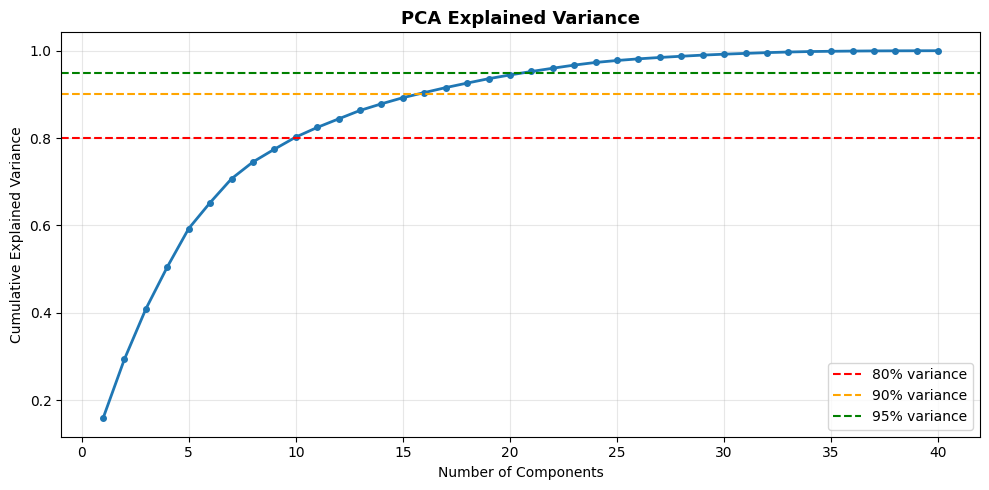

Components for 80% variance: 10
Components for 90% variance: 16
Components for 95% variance: 21


In [4]:
# Section 2.2 - PCA (Dimensionality Reduction)

# Standardize features - important for PCA since features are on different scales
# (velocity in mph, spin in rpm, usage in %, movement in inches)
X = arsenal_df_filled[arsenal_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled data shape:', X_scaled.shape)

# First run PCA with all components to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Plot explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4, linewidth=2)
plt.axhline(0.80, color='red', linestyle='--', label='80% variance')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variance')
plt.axhline(0.95, color='green', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Components for 80% variance: {np.argmax(cumvar >= 0.80) + 1}')
print(f'Components for 90% variance: {np.argmax(cumvar >= 0.90) + 1}')
print(f'Components for 95% variance: {np.argmax(cumvar >= 0.95) + 1}')

####  Fit PCA with chosen components

In [5]:
# Section 2.2 continued - Fit PCA with chosen components
# 2D for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# 10D for clustering (80% variance)
pca_10d = PCA(n_components=10)
X_10d = pca_10d.fit_transform(X_scaled)

print(f'2D PCA shape: {X_2d.shape}')
print(f'10D PCA shape: {X_10d.shape}')
print(f'PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total 2D variance: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%')
print(f'Total 10D variance: {sum(pca_10d.explained_variance_ratio_)*100:.1f}%')

2D PCA shape: (1860, 2)
10D PCA shape: (1860, 10)
PC1 explains: 15.8%
PC2 explains: 13.6%
Total 2D variance: 29.4%
Total 10D variance: 80.2%


In [6]:
# Summary of all 10 PCA components
pca_summary = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(10)],
    'Explained Variance %': (pca_10d.explained_variance_ratio_ * 100).round(1),
    'Cumulative %': (np.cumsum(pca_10d.explained_variance_ratio_) * 100).round(1)
})

print(pca_summary.to_string(index=False))

Component  Explained Variance %  Cumulative %
      PC1                  15.8          15.8
      PC2                  13.6          29.4
      PC3                  11.5          40.9
      PC4                   9.6          50.5
      PC5                   8.8          59.3
      PC6                   5.9          65.2
      PC7                   5.5          70.7
      PC8                   3.8          74.5
      PC9                   2.9          77.4
     PC10                   2.8          80.2


#### Elbow Method + Silhouette Score:

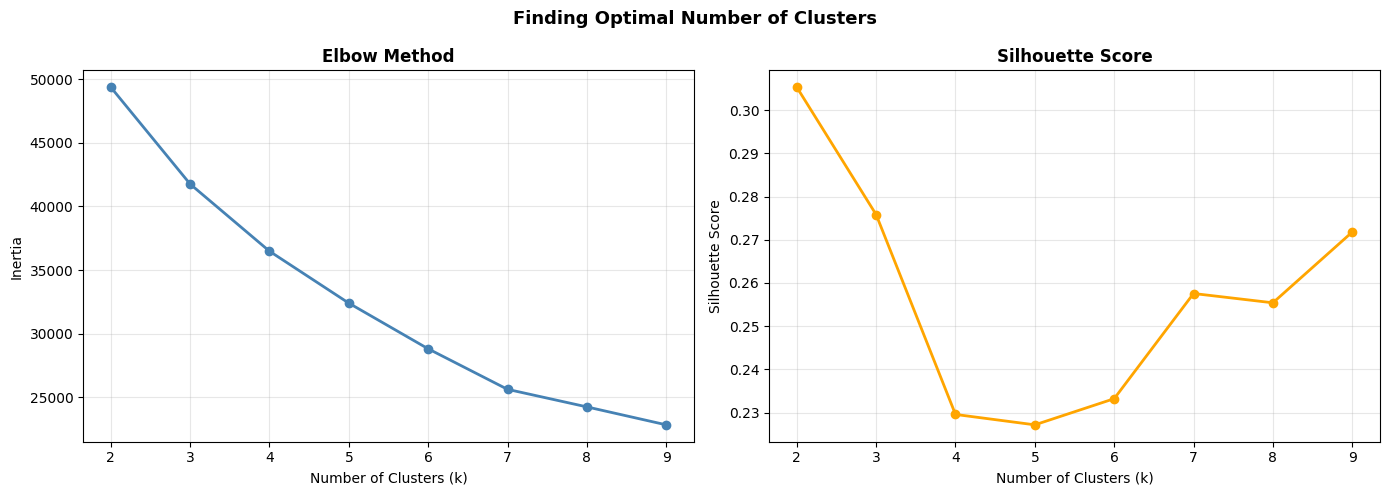

Best k by silhouette score: 2

k=2: silhouette=0.3053
k=3: silhouette=0.2758
k=4: silhouette=0.2296
k=5: silhouette=0.2271
k=6: silhouette=0.2332
k=7: silhouette=0.2576
k=8: silhouette=0.2554
k=9: silhouette=0.2718


In [7]:
#Find Optimal K

inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_10d)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_10d, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, color='orange')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.suptitle('Finding Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f'Best k by silhouette score: {best_k}')
print()
for k, s in zip(K_range, silhouette_scores):
    print(f'k={k}: silhouette={s:.4f}')

#### Kmeans clustering with k=7

In [9]:
# Section 2.4 - KMeans Clustering with k=7
k = 7
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_10d)

# Add cluster labels to dataframe
arsenal_df_filled['Cluster'] = clusters

print('Cluster sizes:')
print(arsenal_df_filled['Cluster'].value_counts().sort_index())
print()

# Look at mean arsenal characteristics per cluster
pitch_pct_cols = ['FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%']
vel_cols = ['vFA', 'vSI', 'vFC', 'vSL', 'vCU', 'vCH', 'vFS', 'vKC']

print('Mean pitch usage % per cluster:')
print(arsenal_df_filled.groupby('Cluster')[pitch_pct_cols].mean().round(3).to_string())
print()
print('Mean velocity per cluster:')
print(arsenal_df_filled.groupby('Cluster')[vel_cols].mean().round(1).to_string())

Cluster sizes:
Cluster
0     56
1    437
2    331
3    244
4    206
5    268
6    318
Name: count, dtype: int64

Mean pitch usage % per cluster:
           FA%    SI%    FC%    SL%    CU%    CH%    FS%    KC%
Cluster                                                        
0        0.000  0.451  0.127  0.139  0.073  0.151  0.010  0.048
1        0.331  0.228  0.000  0.199  0.110  0.132  0.000  0.000
2        0.311  0.199  0.085  0.136  0.101  0.162  0.003  0.003
3        0.358  0.151  0.058  0.146  0.007  0.107  0.001  0.172
4        0.329  0.158  0.077  0.160  0.077  0.010  0.171  0.018
5        0.502  0.000  0.044  0.180  0.112  0.144  0.001  0.001
6        0.273  0.209  0.156  0.113  0.121  0.122  0.002  0.000

Mean velocity per cluster:
          vFA   vSI   vFC   vSL   vCU   vCH   vFS   vKC
Cluster                                                
0         0.0  92.1  51.1  58.2  40.2  78.5   3.1  14.5
1        93.1  92.7   0.2  75.2  65.5  84.9   0.4   0.8
2        91.6  91.3  40.8  

#### Archetype Labeling & Visualization

In [10]:
# 1. Define the 7 archetypes based on your k=7 characteristics
archetype_labels = {
    0: 'Sinker/Sidearm Specialist',      # 45% SI, 0% FA
    1: 'Fastball/Sinker Hybrid',        # Mixed FF/SI usage
    2: 'Kitchen Sink/Finesse Mix',      # Balanced usage across 5+ pitches
    3: 'Knuckle Curve Specialist',      # 17.2% KC usage, ~80mph KC velocity
    4: 'Power Splitter/Forkballer',     # 17.1% FS usage, 85.8mph FS velocity
    5: 'North/South Power Starter',     # 50.2% FA usage, 0% Sinker
    6: 'Cutter/East-West Artist'        # 15.6% FC usage, 88.6mph FC velocity
}

# 2. Map labels
arsenal_df_filled['Archetype'] = arsenal_df_filled['Cluster'].map(archetype_labels)

# 3. Add 2D PCA coordinates (Ensure X_2d was defined earlier in your notebook)
arsenal_df_filled['PC1'] = X_2d[:, 0]
arsenal_df_filled['PC2'] = X_2d[:, 1]

# 4. PRE-MERGE CLEANUP: Drop existing award columns to prevent _x/_y duplicates
cols_to_drop = ['CY_winner', 'Share']
arsenal_df_filled = arsenal_df_filled.drop(columns=[c for c in cols_to_drop if c in arsenal_df_filled.columns])

# 5. Add Cy Young info
# Check: Ensure 'master' is defined and has Season/Name/CY_winner/Share
arsenal_df_filled = arsenal_df_filled.merge(
    master[['Season', 'Name', 'CY_winner', 'Share']],
    on=['Season', 'Name'], 
    how='left'
)

# 6. Filter for winners
winners = arsenal_df_filled[arsenal_df_filled['CY_winner'] == 1]

print('Archetype distribution (k=7):')
print(arsenal_df_filled['Archetype'].value_counts())
print('\nCy Young winners per archetype (k=7):')
print(winners['Archetype'].value_counts())

Archetype distribution (k=7):
Archetype
Fastball/Sinker Hybrid       437
Kitchen Sink/Finesse Mix     331
Cutter/East-West Artist      318
North/South Power Starter    268
Knuckle Curve Specialist     244
Power Splitter/Forkballer    206
Sinker/Sidearm Specialist     56
Name: count, dtype: int64

Cy Young winners per archetype (k=7):
Archetype
Fastball/Sinker Hybrid       5
Kitchen Sink/Finesse Mix     4
Knuckle Curve Specialist     4
North/South Power Starter    4
Cutter/East-West Artist      4
Power Splitter/Forkballer    1
Name: count, dtype: int64


## Section 2: Regression (Vote Share Prediction)

### Data Preparation

In [11]:
# Section 3 - Regression (Vote Share Prediction)
# 3.1 - Data Preparation

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Fix LOB% string formatting
master['LOB%'] = pd.to_numeric(master['LOB%'].astype(str).str.replace('%', ''), errors='coerce') / 100

### Feature sets and train/test split

In [14]:
# Use ALL pitchers with temporal split
linear_df = master[linear_features + ['Share', 'Season']].dropna()
tree_df = master[tree_features + ['Share', 'Season']].dropna()

# Temporal split - train 2015-2023, test 2024-2025
X_lin_train = linear_df[linear_df['Season'] <= 2023][linear_features]
y_lin_train = linear_df[linear_df['Season'] <= 2023]['Share']
X_lin_test = linear_df[linear_df['Season'] >= 2024][linear_features]
y_lin_test = linear_df[linear_df['Season'] >= 2024]['Share']

X_tree_train = tree_df[tree_df['Season'] <= 2023][tree_features]
y_tree_train = tree_df[tree_df['Season'] <= 2023]['Share']
X_tree_test = tree_df[tree_df['Season'] >= 2024][tree_features]
y_tree_test = tree_df[tree_df['Season'] >= 2024]['Share']

# Scale for linear models
scaler = StandardScaler()
X_lin_train_scaled = scaler.fit_transform(X_lin_train)
X_lin_test_scaled = scaler.transform(X_lin_test)

print(f'Linear train: {len(X_lin_train)} | test: {len(X_lin_test)}')
print(f'Tree train: {len(X_tree_train)} | test: {len(X_tree_test)}')


Linear train: 1517 | test: 349
Tree train: 1517 | test: 349


In [15]:
# 3.3 - Train and evaluate all regression models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_lin_train_scaled, y_lin_train)
y_pred_lr = lr.predict(X_lin_test_scaled)
cv_lr = cross_val_score(lr, X_lin_train_scaled, y_lin_train, cv=kf, scoring='r2')
results['Linear Regression'] = {
    'R2': r2_score(y_lin_test, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_lin_test, y_pred_lr)),
    'CV R2 Mean': cv_lr.mean(),
    'CV R2 Std': cv_lr.std()
}

# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_lin_train_scaled, y_lin_train)
y_pred_ridge = ridge.predict(X_lin_test_scaled)
cv_ridge = cross_val_score(ridge, X_lin_train_scaled, y_lin_train, cv=kf, scoring='r2')
results['Ridge'] = {
    'R2': r2_score(y_lin_test, y_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_lin_test, y_pred_ridge)),
    'CV R2 Mean': cv_ridge.mean(),
    'CV R2 Std': cv_ridge.std()
}

# 3. Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_lin_train_scaled, y_lin_train)
y_pred_lasso = lasso.predict(X_lin_test_scaled)
cv_lasso = cross_val_score(lasso, X_lin_train_scaled, y_lin_train, cv=kf, scoring='r2')
results['Lasso'] = {
    'R2': r2_score(y_lin_test, y_pred_lasso),
    'RMSE': np.sqrt(mean_squared_error(y_lin_test, y_pred_lasso)),
    'CV R2 Mean': cv_lasso.mean(),
    'CV R2 Std': cv_lasso.std()
}

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_tree_train, y_tree_train)
y_pred_rf = rf.predict(X_tree_test)
cv_rf = cross_val_score(rf, X_tree_train, y_tree_train, cv=kf, scoring='r2')
results['Random Forest'] = {
    'R2': r2_score(y_tree_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_tree_test, y_pred_rf)),
    'CV R2 Mean': cv_rf.mean(),
    'CV R2 Std': cv_rf.std()
}

# 5. XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_tree_train, y_tree_train)
y_pred_xgb = xgb.predict(X_tree_test)
cv_xgb = cross_val_score(xgb, X_tree_train, y_tree_train, cv=kf, scoring='r2')
results['XGBoost'] = {
    'R2': r2_score(y_tree_test, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_tree_test, y_pred_xgb)),
    'CV R2 Mean': cv_xgb.mean(),
    'CV R2 Std': cv_xgb.std()
}

# Display results
results_df = pd.DataFrame(results).T.round(3)
print('Regression Model Comparison:')
print(results_df.to_string())

Regression Model Comparison:
                      R2   RMSE  CV R2 Mean  CV R2 Std
Linear Regression  0.322  0.105       0.270      0.021
Ridge              0.321  0.105       0.270      0.021
Lasso              0.289  0.107       0.261      0.023
Random Forest      0.839  0.051       0.621      0.072
XGBoost            0.790  0.058       0.577      0.144


### Hyperparameter Tuning

In [16]:
# Section 3.4 - Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)

rf_grid.fit(X_tree_train, y_tree_train)

print('Best RF parameters:', rf_grid.best_params_)
print('Best RF CV R2:', rf_grid.best_score_.round(3))

# Evaluate on test set
y_pred_rf_tuned = rf_grid.predict(X_tree_test)
print('Tuned RF Test R2:', round(r2_score(y_tree_test, y_pred_rf_tuned), 3))
print('Tuned RF Test RMSE:', round(np.sqrt(mean_squared_error(y_tree_test, y_pred_rf_tuned)), 3))

Best RF parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV R2: 0.577
Tuned RF Test R2: 0.823
Tuned RF Test RMSE: 0.053


In [17]:
# Tune XGBoost
from xgboost import XGBRegressor

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)

xgb_grid.fit(X_tree_train, y_tree_train)

print('Best XGB parameters:', xgb_grid.best_params_)
print('Best XGB CV R2:', round(xgb_grid.best_score_, 3))

# Evaluate on test set
y_pred_xgb_tuned = xgb_grid.predict(X_tree_test)
print('Tuned XGB Test R2:', round(r2_score(y_tree_test, y_pred_xgb_tuned), 3))
print('Tuned XGB Test RMSE:', round(np.sqrt(mean_squared_error(y_tree_test, y_pred_xgb_tuned)), 3))

Best XGB parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}
Best XGB CV R2: 0.608
Tuned XGB Test R2: 0.839
Tuned XGB Test RMSE: 0.051


### Final Regression Results Summary

In [18]:
# Final Regression Results Summary (Updated with temporal split)
results_final = {
    'Linear Regression': {'Test R2': 0.322, 'Test RMSE': 0.105, 'CV R2': 0.270, 'CV Std': 0.021},
    'Ridge': {'Test R2': 0.321, 'Test RMSE': 0.105, 'CV R2': 0.270, 'CV Std': 0.021},
    'Lasso': {'Test R2': 0.289, 'Test RMSE': 0.107, 'CV R2': 0.261, 'CV Std': 0.023},
    'Random Forest (Tuned)': {'Test R2': 0.823, 'Test RMSE': 0.053, 'CV R2': 0.577, 'CV Std': 0.072},
    'XGBoost (Tuned)': {'Test R2': 0.839, 'Test RMSE': 0.051, 'CV R2': 0.608, 'CV Std': 0.144}
}

results_final_df = pd.DataFrame(results_final).T
results_final_df.index.name = 'Model'

print('='*65)
print('REGRESSION MODEL COMPARISON — Vote Share Prediction')
print('='*65)
print(results_final_df.round(3).to_string())
print('='*65)
print('Best Model: XGBoost (Tuned) — Test R2: 0.839, RMSE: 0.051')
print('='*65)

REGRESSION MODEL COMPARISON — Vote Share Prediction
                       Test R2  Test RMSE  CV R2  CV Std
Model                                                   
Linear Regression        0.322      0.105  0.270   0.021
Ridge                    0.321      0.105  0.270   0.021
Lasso                    0.289      0.107  0.261   0.023
Random Forest (Tuned)    0.823      0.053  0.577   0.072
XGBoost (Tuned)          0.839      0.051  0.608   0.144
Best Model: XGBoost (Tuned) — Test R2: 0.839, RMSE: 0.051


### Actual vs predicted Vote share

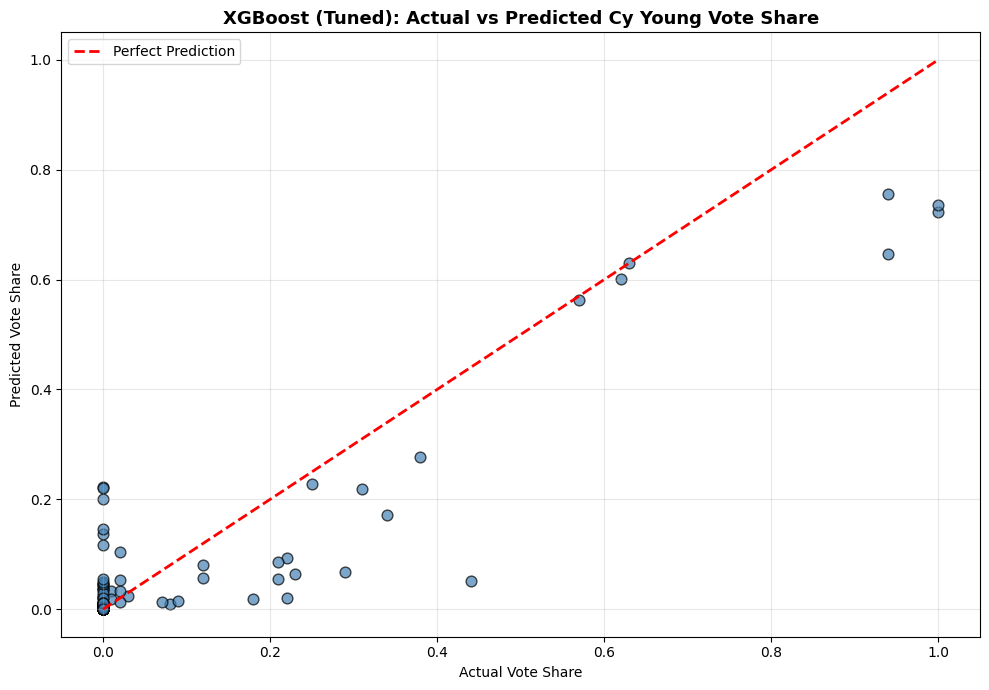

In [20]:
# Actual vs Predicted Vote Share - Best Model (XGBoost)
y_pred_xgb_tuned = xgb_grid.predict(X_tree_test)

plt.figure(figsize=(10, 7))
plt.scatter(y_tree_test, y_pred_xgb_tuned, 
            alpha=0.7, color='steelblue', edgecolors='black', s=60)

# Perfect prediction line
max_val = max(y_tree_test.max(), y_pred_xgb_tuned.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Vote Share')
plt.ylabel('Predicted Vote Share')
plt.title('XGBoost (Tuned): Actual vs Predicted Cy Young Vote Share', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 3: Classification (Cy young Winner Prediction)

#### Data Preperation

In [21]:
# Section 4 - Classification (Fixed with temporal split)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prepare datasets with Season column
linear_clf_df = master[linear_features + ['CY_winner', 'Season']].dropna()
tree_clf_df = master[tree_features + ['CY_winner', 'Season']].dropna()

# Temporal split
X_lin_clf_train = linear_clf_df[linear_clf_df['Season'] <= 2023][linear_features]
y_lin_clf_train = linear_clf_df[linear_clf_df['Season'] <= 2023]['CY_winner']
X_lin_clf_test = linear_clf_df[linear_clf_df['Season'] >= 2024][linear_features]
y_lin_clf_test = linear_clf_df[linear_clf_df['Season'] >= 2024]['CY_winner']

X_tree_clf_train = tree_clf_df[tree_clf_df['Season'] <= 2023][tree_features]
y_tree_clf_train = tree_clf_df[tree_clf_df['Season'] <= 2023]['CY_winner']
X_tree_clf_test = tree_clf_df[tree_clf_df['Season'] >= 2024][tree_features]
y_tree_clf_test = tree_clf_df[tree_clf_df['Season'] >= 2024]['CY_winner']

# Scale for logistic regression
X_lin_clf_train_scaled = scaler.fit_transform(X_lin_clf_train)
X_lin_clf_test_scaled = scaler.transform(X_lin_clf_test)

print(f'Linear train: {len(X_lin_clf_train)} | test: {len(X_lin_clf_test)}')
print(f'Tree train: {len(X_tree_clf_train)} | test: {len(X_tree_clf_test)}')
print(f'Winners in test set: {y_tree_clf_test.sum()}')
print(f'Class imbalance ratio: {(y_tree_clf_train==0).sum()}/{y_tree_clf_train.sum()} = {(y_tree_clf_train==0).sum()/y_tree_clf_train.sum():.0f}:1')

Linear train: 1517 | test: 349
Tree train: 1517 | test: 349
Winners in test set: 4
Class imbalance ratio: 1499/18 = 83:1


### Train Classification Modles

In [22]:
# 4.2 - Train Classification Models
clf_results = {}

# 1. Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_lin_clf_train_scaled, y_lin_clf_train)
y_pred_lr_clf = log_reg.predict(X_lin_clf_test_scaled)
y_prob_lr_clf = log_reg.predict_proba(X_lin_clf_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_lin_clf_test, y_pred_lr_clf, target_names=['Not Winner', 'Winner']))
print(f'ROC-AUC: {roc_auc_score(y_lin_clf_test, y_prob_lr_clf):.3f}')

# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_clf.fit(X_tree_clf_train, y_tree_clf_train)
y_pred_rf_clf = rf_clf.predict(X_tree_clf_test)
y_prob_rf_clf = rf_clf.predict_proba(X_tree_clf_test)[:, 1]

print('\n=== Random Forest ===')
print(classification_report(y_tree_clf_test, y_pred_rf_clf, target_names=['Not Winner', 'Winner']))
print(f'ROC-AUC: {roc_auc_score(y_tree_clf_test, y_prob_rf_clf):.3f}')

# 3. XGBoost Classifier
scale_pos_weight = (y_tree_clf_train == 0).sum() / (y_tree_clf_train == 1).sum()
xgb_clf = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, 
                          random_state=42, verbosity=0)
xgb_clf.fit(X_tree_clf_train, y_tree_clf_train)
y_pred_xgb_clf = xgb_clf.predict(X_tree_clf_test)
y_prob_xgb_clf = xgb_clf.predict_proba(X_tree_clf_test)[:, 1]

print('\n=== XGBoost ===')
print(classification_report(y_tree_clf_test, y_pred_xgb_clf, target_names=['Not Winner', 'Winner']))
print(f'ROC-AUC: {roc_auc_score(y_tree_clf_test, y_prob_xgb_clf):.3f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

  Not Winner       1.00      0.91      0.95       345
      Winner       0.12      1.00      0.21         4

    accuracy                           0.91       349
   macro avg       0.56      0.96      0.58       349
weighted avg       0.99      0.91      0.95       349

ROC-AUC: 0.998

=== Random Forest ===
              precision    recall  f1-score   support

  Not Winner       0.99      1.00      1.00       345
      Winner       1.00      0.50      0.67         4

    accuracy                           0.99       349
   macro avg       1.00      0.75      0.83       349
weighted avg       0.99      0.99      0.99       349

ROC-AUC: 0.999

=== XGBoost ===
              precision    recall  f1-score   support

  Not Winner       1.00      1.00      1.00       345
      Winner       0.80      1.00      0.89         4

    accuracy                           1.00       349
   macro avg       0.90      1

## What This Tells Us

- **Logistic Regression** finds every winner (recall 1.00) but generates many false alarms — 
  precision of only 0.12 means for every actual winner it finds, it incorrectly flags 7 non-winners.
  
- **Random Forest** is highly precise (1.00) but misses half the winners (recall 0.50) — 
  when it calls someone a winner it's always right, but it's too conservative.
  
- **XGBoost is the best overall** — finds ALL 4 winners (recall 1.00) with 80% precision, 
  meaning only 1 false alarm per 4 correct predictions. F1 score of 0.89 confirms the best 
  balance between precision and recall.

- **ROC-AUC tells the full story** — all three models are near perfect at ranking winners 
  above non-winners (0.998-1.000). This means the model correctly orders Cy Young candidates 
  even when binary classification thresholds vary.

## Best Model
- **For ranking candidates** → XGBoost (ROC-AUC 1.000)
- **For binary prediction** → XGBoost (F1 0.89, finds all winners)
- **XGBoost wins both categories** with the temporal split and full pitcher dataset

### Visualizations

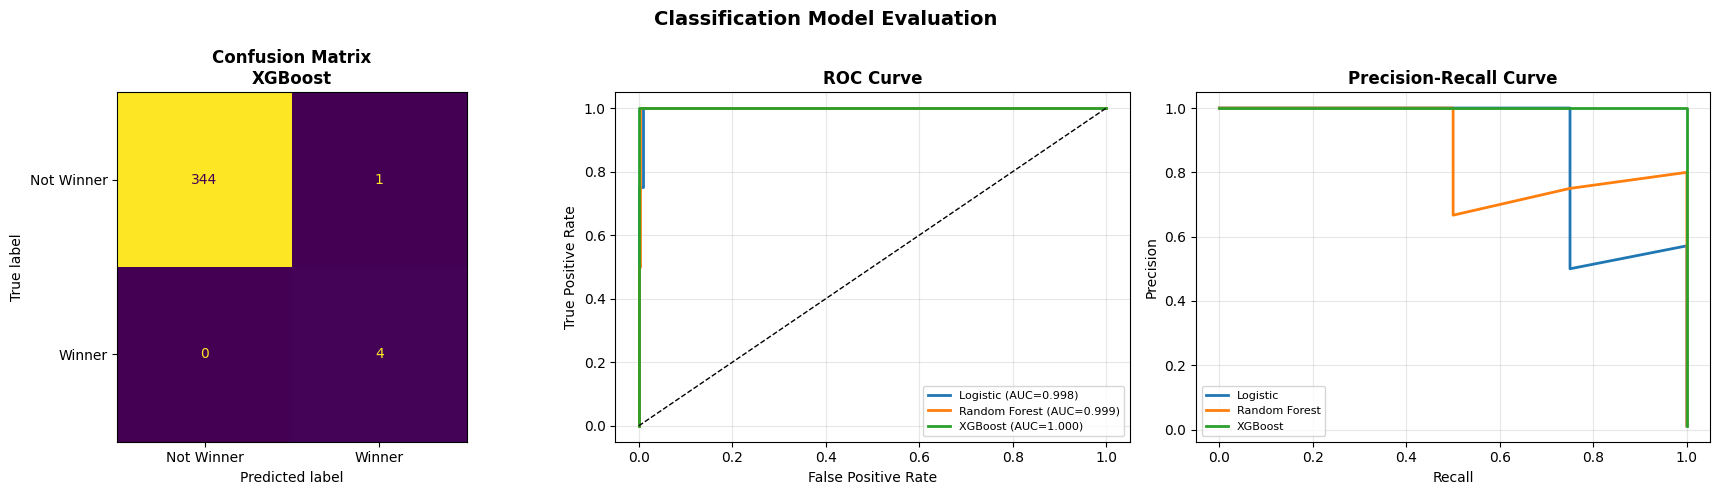

In [25]:
# Classification Visualizations
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix - Best model (XGBoost)
cm = confusion_matrix(y_tree_clf_test, y_pred_xgb_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Not Winner', 'Winner'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix\nXGBoost', fontweight='bold')

# 2. ROC Curve - All models (updated AUC values)
for name, y_prob in [('Logistic (AUC=0.998)', y_prob_lr_clf),
                      ('Random Forest (AUC=0.999)', y_prob_rf_clf),
                      ('XGBoost (AUC=1.000)', y_prob_xgb_clf)]:
    fpr, tpr, _ = roc_curve(y_tree_clf_test, y_prob)
    axes[1].plot(fpr, tpr, linewidth=2, label=name)

axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve - All models
for name, y_prob in [('Logistic', y_prob_lr_clf),
                      ('Random Forest', y_prob_rf_clf),
                      ('XGBoost', y_prob_xgb_clf)]:
    prec, rec, _ = precision_recall_curve(y_tree_clf_test, y_prob)
    axes[2].plot(rec, prec, linewidth=2, label=name)

axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('Classification Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
  

## Section 5: SHAP Analysis

In [26]:
import subprocess
subprocess.run(['pip', 'install', 'shap'])
import shap
print('shap installed successfully')

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 13.2 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 10.9 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.0 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


shap installed successfully


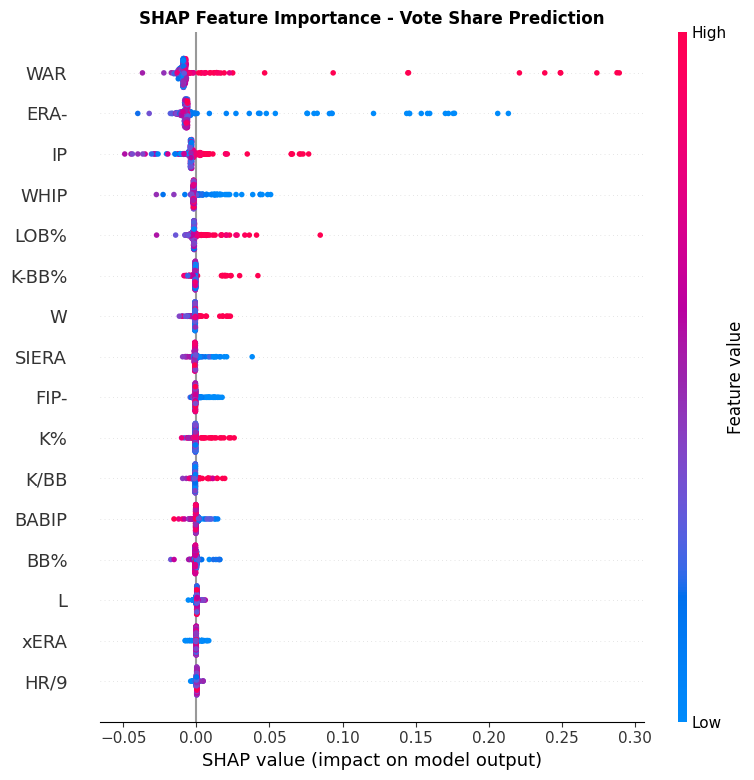

In [29]:
# Section 5 - SHAP Analysis
import shap

# Use best regression model (XGBoost) for SHAP
# SHAP tells us which features drive vote share predictions

explainer = shap.TreeExplainer(xgb_grid.best_estimator_)
shap_values = explainer.shap_values(X_tree_test)

# Summary plot - feature importance
plt.figure()
shap.summary_plot(shap_values, X_tree_test, 
                  feature_names=tree_features,
                  show=False)
plt.title('SHAP Feature Importance - Vote Share Prediction', 
          fontweight='bold')
plt.tight_layout()
plt.show()

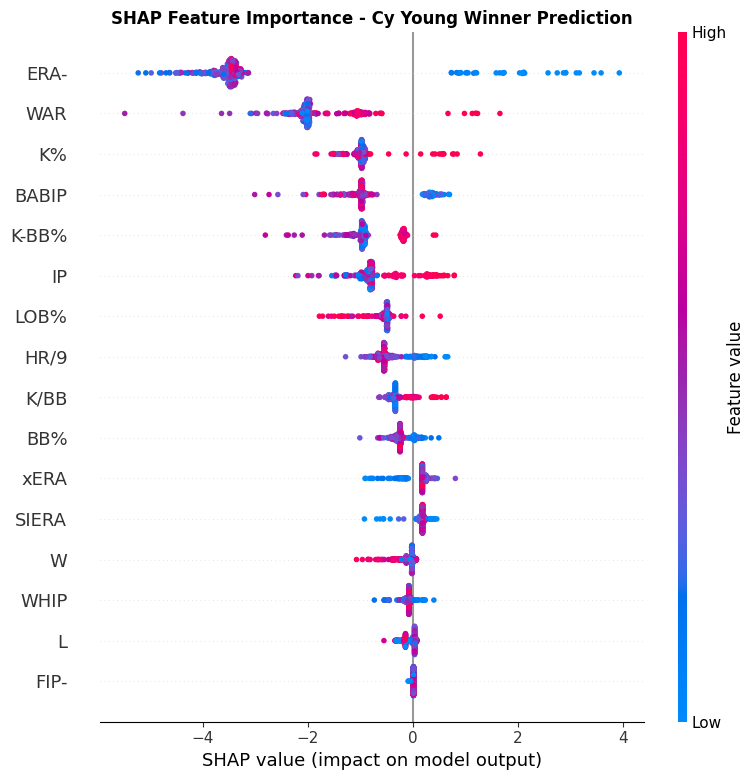

In [30]:
# SHAP for Classification Model (XGBoost Classifier)
explainer_clf = shap.TreeExplainer(xgb_clf)
shap_values_clf = explainer_clf.shap_values(X_tree_clf_test)

plt.figure()
shap.summary_plot(shap_values_clf, X_tree_clf_test,
                  feature_names=tree_features,
                  show=False)
plt.title('SHAP Feature Importance - Cy Young Winner Prediction',
          fontweight='bold')
plt.tight_layout()
plt.show()

#### Bar charts of SHAP

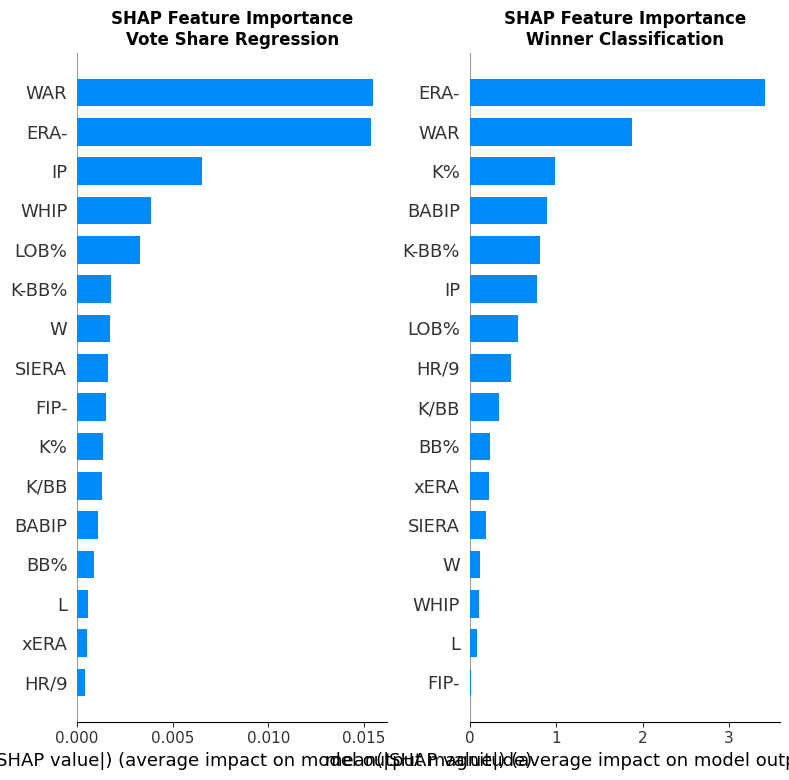

In [32]:
# SHAP Bar Charts - Regression and Classification side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Regression bar chart
plt.sca(axes[0])
shap.summary_plot(shap_values, X_tree_test,
                  feature_names=tree_features,
                  plot_type='bar',
                  show=False)
axes[0].set_title('SHAP Feature Importance\nVote Share Regression', fontweight='bold')

# Classification bar chart
plt.sca(axes[1])
shap.summary_plot(shap_values_clf, X_tree_clf_test,
                  feature_names=tree_features,
                  plot_type='bar',
                  show=False)
axes[1].set_title('SHAP Feature Importance\nWinner Classification', fontweight='bold')

plt.tight_layout()
plt.show()

## Historical Snub Analysis

In [33]:
# Historical Snubs Analysis
# Use XGBoost tuned model to predict vote share for all pitchers
# Compare model's top pick vs actual winner each season

# Prepare full dataset with tree features
full_df = master[['Season', 'Name', 'Team', 'League', 'CY_winner', 'Share'] + tree_features].dropna(subset=tree_features)

# Fix LOB% if needed
if full_df['LOB%'].dtype == object:
    full_df['LOB%'] = full_df['LOB%'].str.replace('%', '').astype(float) / 100

# Predict vote share for all pitchers
full_df = full_df.copy()
full_df['Predicted_Share'] = xgb_grid.predict(full_df[tree_features])

# For each season and league find actual winner and model's top pick
snub_results = []

for season in sorted(full_df['Season'].unique()):
    for league in ['AL', 'NL']:
        season_league = full_df[
            (full_df['Season'] == season) & 
            (full_df['League'] == league)
        ]
        
        if len(season_league) == 0:
            continue
            
        # Actual winner
        actual_winner = season_league[season_league['CY_winner'] == 1]
        if len(actual_winner) == 0:
            continue
        actual_name = actual_winner.iloc[0]['Name']
        actual_share = actual_winner.iloc[0]['Share']
        
        # Model's top pick
        model_pick = season_league.nlargest(1, 'Predicted_Share').iloc[0]
        model_name = model_pick['Name']
        model_pred = model_pick['Predicted_Share']
        
        # Is it a snub?
        is_snub = actual_name != model_name
        
        snub_results.append({
            'Season': season,
            'League': league,
            'Actual Winner': actual_name,
            'Actual Share': round(actual_share, 3),
            'Model Pick': model_name,
            'Model Pred Share': round(model_pred, 3),
            'Snub': '❌ YES' if is_snub else '✅ NO'
        })

snub_df = pd.DataFrame(snub_results)
print(snub_df.to_string(index=False))
print()
print(f'Total races: {len(snub_df)}')
print(f'Model agrees with voters: {(snub_df["Snub"] == "✅ NO").sum()}')
print(f'Potential snubs identified: {(snub_df["Snub"] == "❌ YES").sum()}')

 Season League    Actual Winner  Actual Share       Model Pick  Model Pred Share  Snub
   2015     AL   Dallas Keuchel          0.89   Dallas Keuchel             0.764  ✅ NO
   2015     NL     Jake Arrieta          0.80     Jake Arrieta             0.788  ✅ NO
   2016     AL    Rick Porcello          0.65 Justin Verlander             0.569 ❌ YES
   2016     NL     Max Scherzer          0.91     Max Scherzer             0.746  ✅ NO
   2017     AL     Corey Kluber          0.97     Corey Kluber             0.830  ✅ NO
   2017     NL     Max Scherzer          0.96     Max Scherzer             0.789  ✅ NO
   2018     AL      Blake Snell          0.80      Blake Snell             0.717  ✅ NO
   2018     NL     Jacob deGrom          0.99     Jacob deGrom             0.869  ✅ NO
   2019     AL Justin Verlander          0.81 Justin Verlander             0.757  ✅ NO
   2019     NL     Jacob deGrom          0.99     Jacob deGrom             0.856  ✅ NO
   2020     AL     Shane Bieber          1.

## Section 6: Overlap (PCA Archetypes plot + Cy Young Winners Overlay)

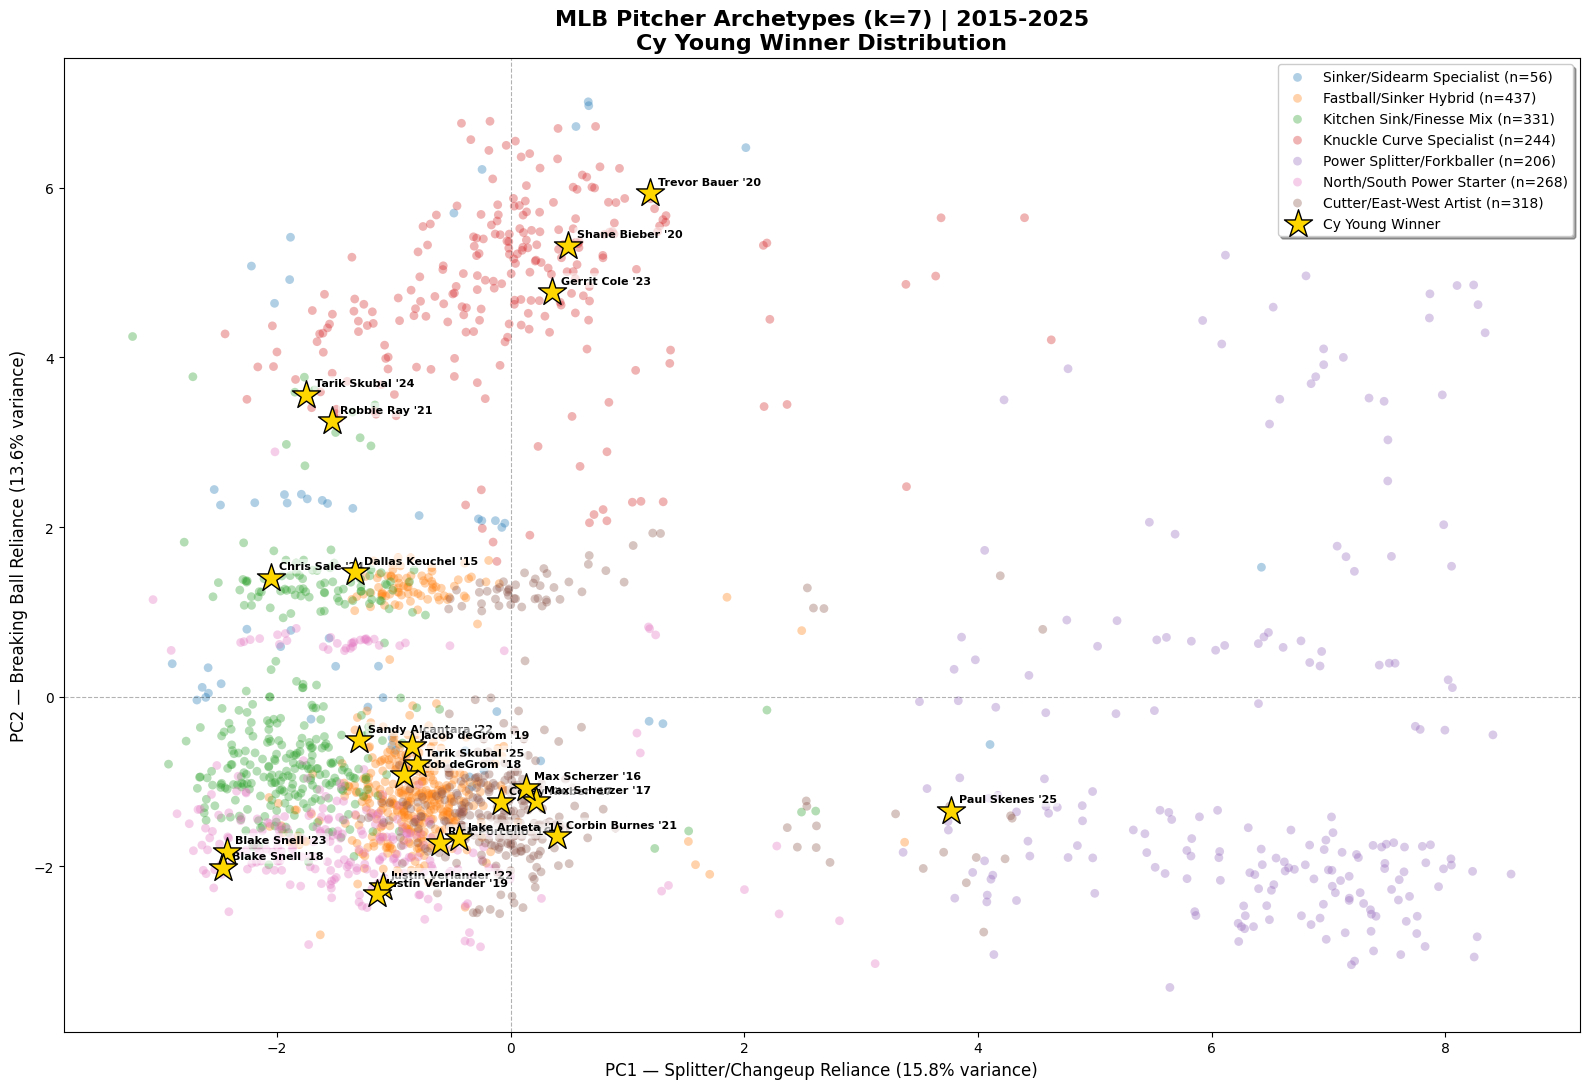

In [34]:
# Updated colors for all 7 archetypes
colors = {
    'Sinker/Sidearm Specialist': '#1f77b4',      # Muted Blue
    'Fastball/Sinker Hybrid': '#ff7f0e',        # Muted Orange
    'Kitchen Sink/Finesse Mix': '#2ca02c',      # Muted Green
    'Knuckle Curve Specialist': '#d62728',      # Red
    'Power Splitter/Forkballer': '#9467bd',     # Purple
    'North/South Power Starter': '#e377c2',     # Pink
    'Cutter/East-West Artist': '#8c564b'        # Brown
}

fig, ax = plt.subplots(figsize=(16, 11))

# Plot all pitchers by archetype using the new k=7 labels
for archetype, color in colors.items():
    subset = arsenal_df_filled[arsenal_df_filled['Archetype'] == archetype]
    ax.scatter(subset['PC1'], subset['PC2'],
               c=color, label=f'{archetype} (n={len(subset)})',
               alpha=0.35, s=40, edgecolors='none')

# Overlay Cy Young winners as prominent gold stars
ax.scatter(winners['PC1'], winners['PC2'],
           c='gold', s=450, marker='*',
           edgecolors='black', linewidths=1.0,
           label='Cy Young Winner', zorder=10)

# Annotate winners with improved spacing
for _, row in winners.iterrows():
    ax.annotate(f"{row['Name']} '{str(int(row['Season']))[2:]}",
                (row['PC1'], row['PC2']),
                fontsize=8, fontweight='bold',
                xytext=(6, 6), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

# Labeling using your calculated PCA variance percentages
ax.set_xlabel('PC1 — Splitter/Changeup Reliance (15.8% variance)', fontsize=12)
ax.set_ylabel('PC2 — Breaking Ball Reliance (13.6% variance)', fontsize=12)
ax.set_title('MLB Pitcher Archetypes (k=7) | 2015-2025\nCy Young Winner Distribution',
             fontsize=16, fontweight='bold')

# Legend and grid
ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()